In [38]:
# pandas for data manipulation
# re for regular expressions
import re

# pyplot for plotting
# numpy for numerical operations
import numpy as np
import pandas as pd
from scipy.signal import stft
from sklearn.decomposition import PCA

# other .py files
from utils.csv_import_data_analysis import get_csv_files_generalistic, sort_meta_info

In [39]:
# Retrieve CSV files

path_to: str = "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project"
path: str = path_to + "\\new_data"

FileMap = dict[str, dict[str, str]]
csi_map = dict[str, dict[str, dict[str, np.ndarray]]]


data_files = get_csv_files_generalistic(path)
scenarios_id, users_id, activities_id, esps_id = sort_meta_info(path)
print(f"Scenarios:  {scenarios_id}")
print(f"Users:      {users_id}")
print(f"Activities: {activities_id}")
print(f"ESPs: 	    {esps_id}")
print("\nData files: ", data_files)

Scenarios:  ['21', '22']
Users:      ['00', '01']
Activities: ['00', '01']
ESPs: 	    ['01', '02', '04', '05', '06', '07']

Data files:  {'scenario_21': {'user_00': {'activity_00': {'esp_01': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_00_00_01_2026-03-05_15-30.csv')], 'esp_02': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_00_00_02_2026-03-05_15-30.csv')], 'esp_04': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_00_00_04_2026-03-05_15-30.csv')]}}, 'user_01': {'activity_01': {'esp_01': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_01_01_01_2026-03-05_16-01.csv')], 'esp_02': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_01_01_02_2026-03-

In [40]:
# Per-packet normalization to mitigate AGC effects.
# magnitude shape: (n_samples, n_subcarriers)

# antes de sacar o AGC (5 GHz)
def calibrate_magnitude(magnitude: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(magnitude, axis=1, keepdims=True)
    norm[norm == 0] = 1  # avoid division by zero
    return magnitude / norm


def apply_pca(magnitude_data, variance_ratio=0.999):
    pca = PCA(n_components=variance_ratio)
    transformed = pca.fit_transform(magnitude_data)
    return transformed, pca


def process_csi(data_file: str, its5ghz: bool) -> np.ndarray:
    file_csv = pd.read_csv(data_file, header=None)

    # number of samples
    if its5ghz:
        print("Com 5 GHz")
        csi_raw: pd.Series = file_csv.iloc[:, 14]
    else:
        csi_raw: pd.Series = file_csv.iloc[:, 25]

    total_sc_2_4_GHz: int = 128
    total_sc_5_GHz: int = 106
    valid_csi: list[list[float]] = []

    # contar CSI inválidos
    no_match_count: int = 0
    no_complete_count: int = 0

    if its5ghz:
        for entry in csi_raw:
            match = re.search(r"\[(.*?)\]", str(entry))
            if not match:
                no_match_count += 1
                continue

            nums = [float(n) for n in re.findall(r"-?\d+", match.group(1))]

            # para já hard coded, mas para mudar
            if len(nums) in [104, 106]:
                valid_csi.append(nums)
            else:
                no_complete_count += 1

    else:
        for entry in csi_raw:
            match = re.search(r"\[(.*?)\]", str(entry))
            if not match:
                no_match_count += 1
                continue

            nums = [float(n) for n in re.findall(r"-?\d+", match.group(1))]

            if len(nums) == total_sc_2_4_GHz:
                valid_csi.append(nums)
            else:
                no_complete_count += 1

    valid_csi = np.array(valid_csi)

    print(f"Total CSI entries: {len(csi_raw)}")
    print(f"Valid CSI entries: {len(valid_csi)}")
    print(f"Invalid CSI entries (no match): {no_match_count}")
    print(f"Invalid CSI entries (incomplete): {no_complete_count}")
    print("Valid CSI shape: ", valid_csi.shape, "\n")

    # (n_amostras, 128)
    complex_csi = valid_csi[:, ::2] + 1j * valid_csi[:, 1::2]

    # coloca sc DC no centro (index 32)
    fft_csi = np.fft.fftshift(complex_csi, axes=1)

    # Extract the 52 active subcarriers (IEEE 802.11n standard): [6:58]
    # (n_amostras, 52)
    active_sc = fft_csi[:, 6:58]

    # Remove subcarriers at positions 25, 26, 27 (center)
    # (n_amostras, 49)
    active_sc = np.delete(active_sc, [25, 26, 27], axis=1)

    # seleciona sub_carriers: 2 a 47
    active_sc = active_sc[:, 2:48]

    return np.abs(active_sc)


def process_magnitude(data_files: FileMap) -> csi_map:
    magnitudes = {}
    its5ghz = False

    for scenario_key, users_map in data_files.items():
        print(f"Processing scenario: {scenario_key}")
        magnitudes[scenario_key] = {}

        for user_key, activities_map in users_map.items():
            magnitudes[scenario_key][user_key] = {}

            for activity, esps_map in activities_map.items():
                magnitudes[scenario_key][user_key][activity] = {}

                for esp, file_path in esps_map.items():
                    if file_path is not None:
                        if "22" in scenario_key or "12" in scenario_key:
                            print(
                                f"Processing 5GHz data for {scenario_key} | {user_key} | {activity} | {esp}"
                            )
                            its5ghz = True
                        path = (
                            file_path[0] if isinstance(file_path, list) else file_path
                        )
                        magnitudes[scenario_key][user_key][activity][esp] = process_csi(
                            str(path), its5ghz
                        )

    return magnitudes

In [41]:
def compute_pca1_variance(pca_features: np.ndarray) -> float:
    pca1 = pca_features[:, 0]
    return np.var(pca1)


def compute_doppler_energy(pca_features: np.ndarray, fs: float = 1000.0):
    pca1 = pca_features[:, 0]

    # Remove mean (remove static component)
    pca1 = pca1 - np.mean(pca1)

    f, t, Zxx = stft(pca1, fs=fs, nperseg=256)

    # Remove DC component (f=0)
    non_zero_idx = f > 0.1

    energy = np.sum(np.abs(Zxx[non_zero_idx, :]) ** 2)

    return energy


def compute_snr_proxy(pca_features: np.ndarray, fs: float = 1000.0):
    pca1 = pca_features[:, 0]
    pca1 = pca1 - np.mean(pca1)

    f, t, Zxx = stft(pca1, fs=fs, nperseg=256)

    power_spectrum = np.abs(Zxx) ** 2

    # Static band (near DC)
    static_idx = f < 0.1

    # Dynamic band
    dynamic_idx = (f >= 0.1) & (f <= 10)

    static_power = np.sum(power_spectrum[static_idx, :])
    dynamic_power = np.sum(power_spectrum[dynamic_idx, :])

    if static_power == 0:
        return 0

    return dynamic_power / static_power

In [42]:
magnitude_data = process_magnitude(data_files)

Processing scenario: scenario_21
Total CSI entries: 190
Valid CSI entries: 150
Invalid CSI entries (no match): 40
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (150, 128) 

Total CSI entries: 247
Valid CSI entries: 189
Invalid CSI entries (no match): 58
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (189, 128) 

Total CSI entries: 272
Valid CSI entries: 176
Invalid CSI entries (no match): 96
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (176, 128) 

Total CSI entries: 496
Valid CSI entries: 354
Invalid CSI entries (no match): 142
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (354, 128) 

Total CSI entries: 521
Valid CSI entries: 387
Invalid CSI entries (no match): 134
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (387, 128) 

Total CSI entries: 569
Valid CSI entries: 392
Invalid CSI entries (no match): 177
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (392, 128) 

Processing scenario: scenario_22
Processing 5GHz data for scenario_22 | user

In [43]:
# define sampling frequency (Hz) as
# the original packet rate/s
fs = 1000

# Compute metrics for each individual CSI file
metrics_per_file = {}

for user_key, activities_map in magnitude_data.items():
    for activity, places_map in activities_map.items():
        for place, esps_map in places_map.items():
            for esp, features in esps_map.items():
                label = f"{user_key}-{activity}-{place}-{esp}"
                metrics_per_file[label] = {
                    "PCA1 Variance": compute_pca1_variance(features),
                    "Doppler Energy": compute_doppler_energy(features, fs),
                    "SNR Proxy": compute_snr_proxy(features, fs),
                }

print(f"Computed metrics for {len(metrics_per_file)} files")


Computed metrics for 12 files


c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 150, using nperseg = 150
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,
c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 189, using nperseg = 189
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,
c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 176, using nperseg = 176
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,


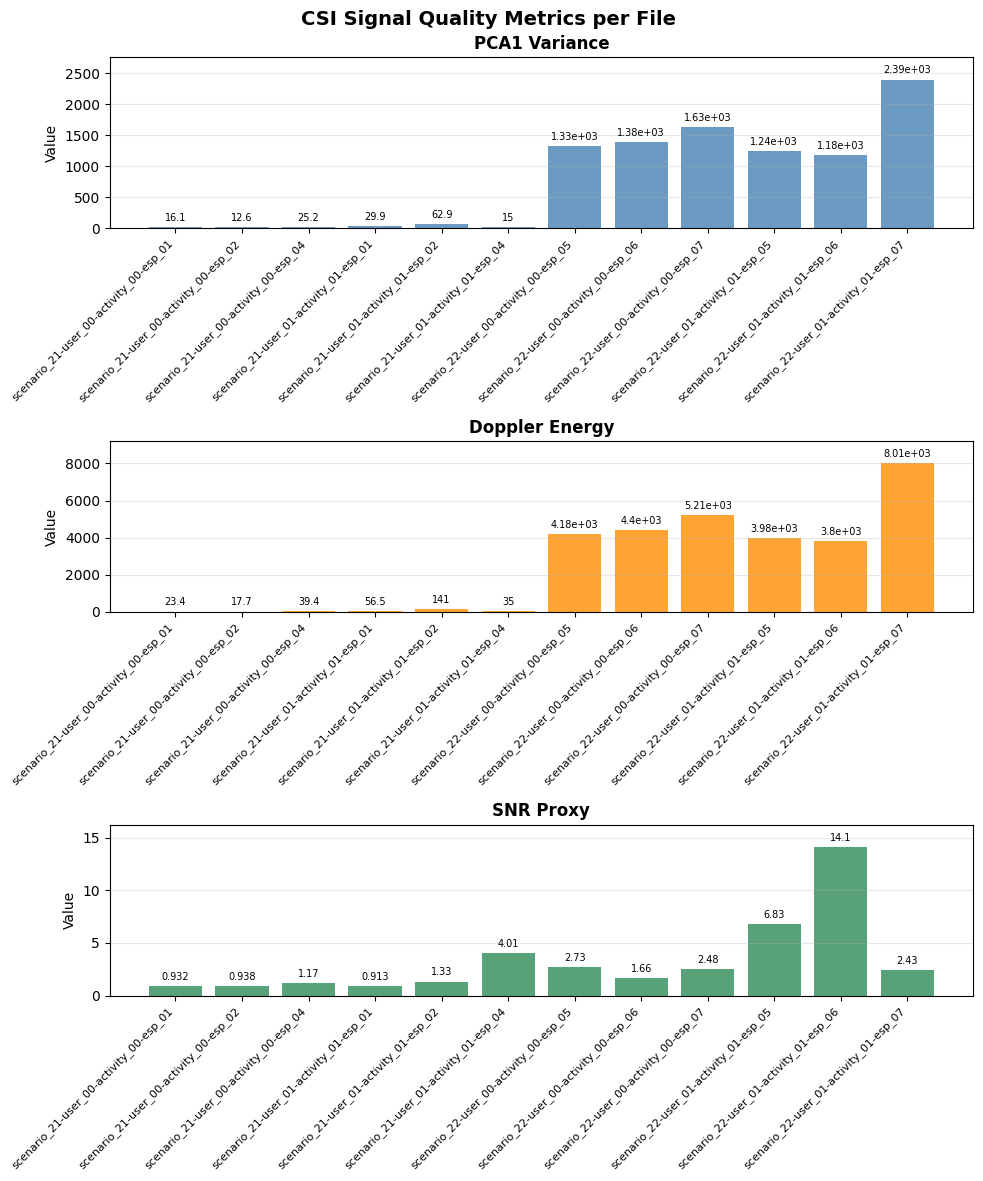

In [44]:
metric_names = ["PCA1 Variance", "Doppler Energy", "SNR Proxy"]
colors = ["steelblue", "darkorange", "seagreen"]
labels = list(metrics_per_file.keys())
x = np.arange(len(labels))

from matplotlib import pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(max(10, len(labels) * 0.8), 12))

for ax, metric, color in zip(axes, metric_names, colors):
    values = [metrics_per_file[lbl][metric] for lbl in labels]
    bars = ax.bar(x, values, color=color, alpha=0.8)
    ax.bar_label(bars, fmt="%.3g", padding=3, fontsize=7)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylabel("Value")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.margins(y=0.15)

fig.suptitle("CSI Signal Quality Metrics per File", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


#### CSI Magnitude vs Number of Packages analysis

Plotting data for user: scenario_21
Plotting data for user: scenario_22


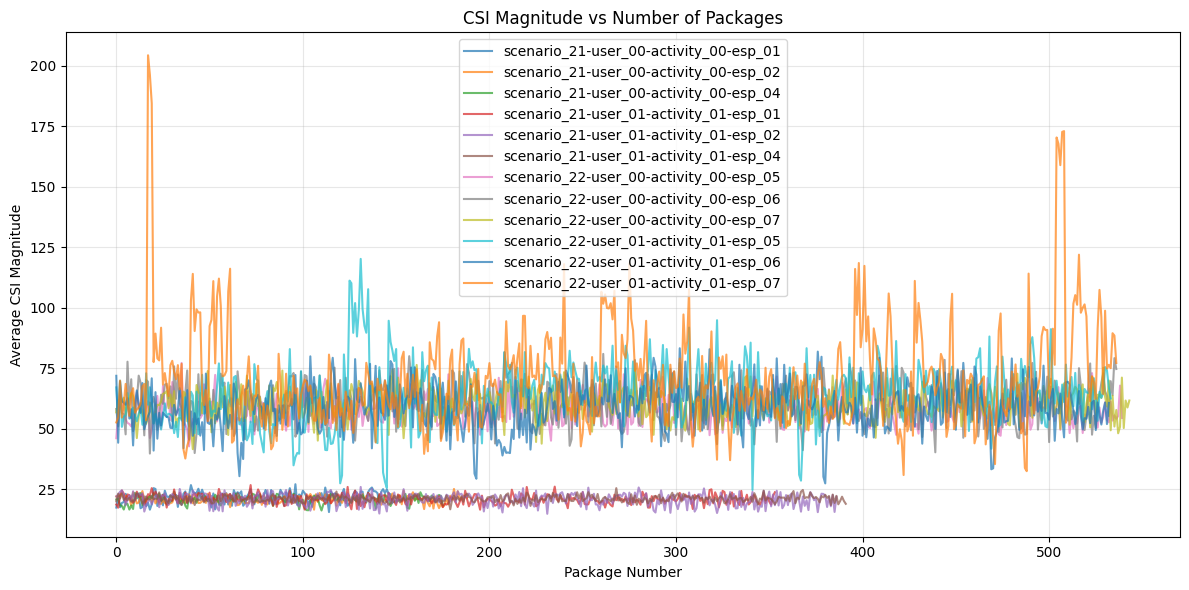

In [45]:
plt.figure(figsize=(12, 6))

for user_key, activities_map in magnitude_data.items():
    print(f"Plotting data for user: {user_key}")
    for activity, places_map in activities_map.items():
        for place, esps_map in places_map.items():
            for esp, csi_magnitude in esps_map.items():
                # Calculate average magnitude across all subcarriers for each packet
                avg_magnitude = csi_magnitude.mean(axis=1)
                n_packets = len(avg_magnitude)

                plt.plot(
                    range(n_packets),
                    avg_magnitude,
                    label=f"{user_key}-{activity}-{place}-{esp}",
                    alpha=0.7,
                )

plt.xlabel("Package Number")
plt.ylabel("Average CSI Magnitude")
plt.title("CSI Magnitude vs Number of Packages")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Dataset

In [46]:
def segment_signal(
    signal: np.ndarray,
    window_size: int,
    overlap: int,
) -> list[np.ndarray]:
    segments: list[np.ndarray] = []

    for i in range(0, signal.shape[0], overlap):
        if i + window_size < signal.shape[0]:
            segment = signal[i : i + window_size]
            segments.append(segment)

    return segments


def process_pipeline(
    csi_magnitude: np.ndarray, window_size: int = 10, overlap_size: int = 2
) -> np.ndarray:
    csi_magnitude = calibrate_magnitude(csi_magnitude)

    pca_features, _ = apply_pca(csi_magnitude, variance_ratio=0.999)

    segmented_data = segment_signal(pca_features, window_size, overlap_size)
    segmented_data = np.array(segmented_data)

    # obtemos 3 matrizes de features: mean e std
    features = [
        np.var(segmented_data[:, :, 0], axis=1),
        np.std(segmented_data[:, :, 0], axis=1),
        np.sum(segmented_data[:, :, 0] ** 2, axis=1),
    ]
    features = np.array(features)

    df_x = np.transpose(features)

    return df_x


def build_scenario_dataset(
    users_map: dict[str, dict[str, dict[str, np.ndarray]]],
    scenario_key: str,
    window_size: int = 10,
    overlap_size: int = 2,
) -> pd.DataFrame:
    rows: list[dict[str, object]] = []

    # Process each (user, activity) combination
    for user_key, activities_map in users_map.items():
        for activity_key, esps_map in activities_map.items():
            print(
                f"Processing: {scenario_key} | {user_key} | {activity_key} | Fusing ESPs"
            )

            # Step 1: Compute window features for each ESP separately
            esp_features = {}
            for esp_key, csi in esps_map.items():
                print(f"  Computing features for {esp_key}")
                window_features = process_pipeline(csi, window_size, overlap_size)
                esp_features[esp_key] = window_features  # shape: (n_windows, 3)

            # Step 2: Find minimum number of windows across all ESPs
            min_windows = min(features.shape[0] for features in esp_features.values())

            if min_windows == 0:
                print(f"  [WARN] No valid windows for {user_key}/{activity_key}, skipping")
                continue

            print(f"  Aligning to {min_windows} windows across {len(esp_features)} ESPs")

            # Step 3: Truncate all ESPs to common window count
            aligned_features = {}
            for esp_key, features in esp_features.items():
                aligned_features[esp_key] = features[:min_windows, :]

            # Step 4: Concatenate features from all ESPs horizontally
            # Sort ESP keys to ensure consistent ordering
            sorted_esp_keys = sorted(aligned_features.keys())
            fused_features = np.concatenate(
                [aligned_features[esp_key] for esp_key in sorted_esp_keys],
                axis=1
            )  # shape: (min_windows, n_esps * 3)

            print(f"  Fused feature shape: {fused_features.shape}")

            # Step 5: Create rows with fused features
            # Generate column names dynamically based on number of ESPs
            feature_names = []
            for esp_key in sorted_esp_keys:
                feature_names.extend([
                    f"variance_{esp_key}",
                    f"std_{esp_key}",
                    f"energy_{esp_key}"
                ])

            for window_idx in range(min_windows):
                row = {
                    "scenario": scenario_key,
                    "user": user_key,
                    "activity": activity_key,
                }
                # Add all fused features
                for feat_idx, feat_name in enumerate(feature_names):
                    row[feat_name] = fused_features[window_idx, feat_idx]

                rows.append(row)

    scenario_df = pd.DataFrame(rows)

    if scenario_df.empty:
        print(f"[WARN] Empty dataset for scenario {scenario_key}")
        return scenario_df

    # Add label column: activity "00" -> 0, activity "01" -> 1
    activity_to_label = {
        "activity_00": 0,
        "activity_01": 1,
    }
    scenario_df["label"] = scenario_df["activity"].map(activity_to_label)

    # Keep only feature columns and label (drop metadata columns)
    feature_cols = [col for col in scenario_df.columns 
				if col.startswith(('variance_', 'std_', 'energy_')) or col == 'label']
    scenario_df = scenario_df[feature_cols]

    print(f"Final dataset: {scenario_df.shape[0]} rows x {scenario_df.shape[1]} columns\n")

    return scenario_df

In [47]:
# Dataset per scenario
dataset_per_scenario: dict[str, pd.DataFrame] = {}

for scenario_key, users_map in magnitude_data.items():
    print(f"Building dataset for scenario {scenario_key}\n")
    dataset_per_scenario[scenario_key] = build_scenario_dataset(users_map, scenario_key)
    print(
        f"Scenario {scenario_key}: {dataset_per_scenario[scenario_key].shape[0]} windows (features + labels)\n\n"
    )

scenario_keys = sorted(dataset_per_scenario.keys())

# Create explicit variables for up to 4 scenarios found in the data
dataset_1 = (
    dataset_per_scenario[scenario_keys[0]] if len(scenario_keys) > 0 else pd.DataFrame()
)
dataset_2 = (
    dataset_per_scenario[scenario_keys[1]] if len(scenario_keys) > 1 else pd.DataFrame()
)

Building dataset for scenario scenario_21

Processing: scenario_21 | user_00 | activity_00 | Fusing ESPs
  Computing features for esp_01
  Computing features for esp_02
  Computing features for esp_04
  Aligning to 70 windows across 3 ESPs
  Fused feature shape: (70, 9)
Processing: scenario_21 | user_01 | activity_01 | Fusing ESPs
  Computing features for esp_01
  Computing features for esp_02
  Computing features for esp_04
  Aligning to 172 windows across 3 ESPs
  Fused feature shape: (172, 9)
Final dataset: 242 rows x 10 columns

Scenario scenario_21: 242 windows (features + labels)


Building dataset for scenario scenario_22

Processing: scenario_22 | user_00 | activity_00 | Fusing ESPs
  Computing features for esp_05
  Computing features for esp_06
  Computing features for esp_07
  Aligning to 264 windows across 3 ESPs
  Fused feature shape: (264, 9)
Processing: scenario_22 | user_01 | activity_01 | Fusing ESPs
  Computing features for esp_05
  Computing features for esp_06
  Comp

In [48]:
for dataset in dataset_per_scenario.values():
    print("Dataset structure (first 5 rows):")
    print(dataset.head())
    print(f"\nDataset shape: {dataset.shape}")
    print(f"Columns: {dataset.columns.tolist()}")
    print(f"Label values: {dataset['label'].unique()}")

    # Show feature dimensions
    feature_cols = [col for col in dataset.columns if col != 'label']
    print(f"Number of fused features: {len(feature_cols)}")
    print()

Dataset structure (first 5 rows):
   variance_esp_01  std_esp_01  energy_esp_01  variance_esp_02  std_esp_02  \
0         0.041216    0.203017       0.419477         0.042416    0.205951   
1         0.041922    0.204749       0.423038         0.042338    0.205762   
2         0.044795    0.211649       0.448831         0.041755    0.204340   
3         0.028349    0.168372       0.381045         0.041795    0.204439   
4         0.028190    0.167899       0.377462         0.043258    0.207986   

   energy_esp_02  variance_esp_04  std_esp_04  energy_esp_04  label  
0       0.424607         0.053498    0.231296       2.050178      0  
1       0.423853         0.053748    0.231837       2.050632      0  
2       0.428811         0.081533    0.285539       1.566226      0  
3       0.431264         0.080885    0.284402       1.309866      0  
4       0.432764         0.068829    0.262353       0.803131      0  

Dataset shape: (242, 10)
Columns: ['variance_esp_01', 'std_esp_01', 'energy_

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

model_results = {}

for scenario_key, dataset in dataset_per_scenario.items():
    if dataset.empty:
        print(f"[SKIP] {scenario_key}: empty dataset")
        continue

    if dataset["label"].nunique() < 2:
        print(f"[SKIP] {scenario_key}: only one label present")
        continue

    # Select all feature columns (excluding 'label')
    feature_cols = [col for col in dataset.columns if col != "label"]
    X = dataset[feature_cols]
    y = dataset["label"]

    print(f"Training with {len(feature_cols)} fused features: {feature_cols[:6]}...")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )

    models = {
        "SVM": make_pipeline(
            StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
        ),
        "RF": RandomForestClassifier(
            n_estimators=300, random_state=42, class_weight="balanced"
        ),
    }

    model_results[scenario_key] = {}

    print(f"\n=== Scenario: {scenario_key} ===")
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro")

        model_results[scenario_key][model_name] = {
            "accuracy": acc,
            "f1_macro": f1_macro,
            "report": classification_report(y_test, y_pred, output_dict=True),
        }

        print(f"\n{model_name}")
        print(f"Accuracy: {acc:.4f}")
        print(f"F1-macro: {f1_macro:.4f}")
        print(classification_report(y_test, y_pred, digits=4))

Training with 9 fused features: ['variance_esp_01', 'std_esp_01', 'energy_esp_01', 'variance_esp_02', 'std_esp_02', 'energy_esp_02']...

=== Scenario: scenario_21 ===

SVM
Accuracy: 0.9796
F1-macro: 0.9755
              precision    recall  f1-score   support

           0     0.9333    1.0000    0.9655        14
           1     1.0000    0.9714    0.9855        35

    accuracy                         0.9796        49
   macro avg     0.9667    0.9857    0.9755        49
weighted avg     0.9810    0.9796    0.9798        49


RF
Accuracy: 1.0000
F1-macro: 1.0000
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        14
           1     1.0000    1.0000    1.0000        35

    accuracy                         1.0000        49
   macro avg     1.0000    1.0000    1.0000        49
weighted avg     1.0000    1.0000    1.0000        49

Training with 9 fused features: ['variance_esp_05', 'std_esp_05', 'energy_esp_05', 'variance_esp_06', 


RF
Accuracy: 1.0000
F1-macro: 1.0000
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        53
           1     1.0000    1.0000    1.0000        53

    accuracy                         1.0000       106
   macro avg     1.0000    1.0000    1.0000       106
weighted avg     1.0000    1.0000    1.0000       106



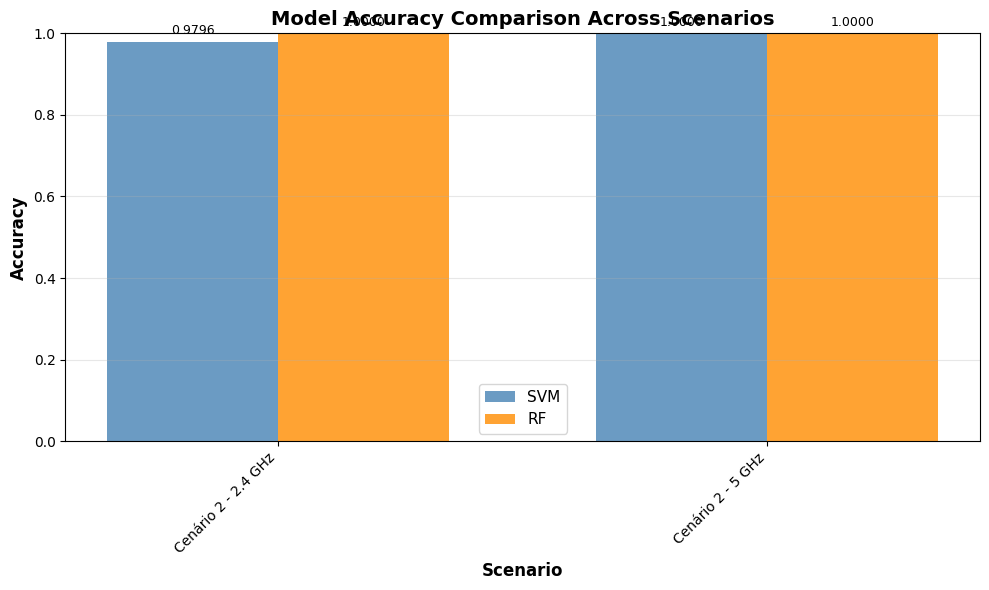

In [50]:
from matplotlib import pyplot as plt

# Extract accuracy results for each scenario and model
scenarios_list = sorted(model_results.keys())
svm_accuracies = []
rf_accuracies = []

for scenario in scenarios_list:
    if "SVM" in model_results[scenario]:
        svm_accuracies.append(model_results[scenario]["SVM"]["accuracy"])
    if "RF" in model_results[scenario]:
        rf_accuracies.append(model_results[scenario]["RF"]["accuracy"])

# Create comparison plot
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(scenarios_list))
width = 0.35

bars1 = ax.bar(
    x - width / 2, svm_accuracies, width, label="SVM", alpha=0.8, color="steelblue"
)
bars2 = ax.bar(
    x + width / 2, rf_accuracies, width, label="RF", alpha=0.8, color="darkorange"
)

ax.set_xlabel("Scenario", fontsize=12, fontweight="bold")
ax.set_ylabel("Accuracy", fontsize=12, fontweight="bold")
ax.set_title(
    "Model Accuracy Comparison Across Scenarios", fontsize=14, fontweight="bold"
)

scenarios = {
    "11": "Cenário 1 - 2.4 GHz",
    "12": "Cenário 1 - 5 GHz",
    "21": "Cenário 2 - 2.4 GHz",
    "22": "Cenário 2 - 5 GHz",
}

ax.set_xticks(x)
ax.set_xticklabels(
    [scenarios.get(key.split("_")[1], key) for key in scenarios_list],
    rotation=45,
    ha="right",
)
ax.set_ylim([0, 1.0])
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

# Add value labels on bars
ax.bar_label(bars1, fmt="%.4f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.4f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## Parameter Study: Window and Overlap Size Impact

In [51]:
# Define window and overlap combinations to test
window_overlap_configs = []
for i in range(1, 10):
    for j in range(30, 50, 5):
        print(f"Window size: {j}, Overlap size: {i}")
        window_overlap_configs.append({"window_size": j, "overlap_size": i})

# Store results for all configurations
param_study_results = {}

for config in window_overlap_configs:
    window_size = config["window_size"]
    overlap_size = config["overlap_size"]
    config_key = f"w{window_size}_o{overlap_size}"

    print(f"\n{'=' * 80}")
    print(f"Testing: Window Size = {window_size}, Overlap Size = {overlap_size}")
    print(f"{'=' * 80}\n")

    # Build datasets with current window/overlap configuration
    dataset_per_scenario_param = {}

    for scenario_key, users_map in magnitude_data.items():
        print(f"Building dataset for scenario {scenario_key}\n")
        scenario_df = build_scenario_dataset(
            users_map,
            scenario_key,
            window_size=window_size,
            overlap_size=overlap_size,
        )
        dataset_per_scenario_param[scenario_key] = scenario_df
        print(f"Scenario {scenario_key}: {scenario_df.shape[0]} windows")

    # Train models for each scenario
    param_study_results[config_key] = {}

    for scenario_key, dataset in dataset_per_scenario_param.items():
        if dataset.empty:
            print(f"[SKIP] {scenario_key}: empty dataset")
            continue

        if dataset["label"].nunique() < 2:
            print(f"[SKIP] {scenario_key}: only one label present")
            continue

        # Select all feature columns (excluding 'label')
        feature_cols = [col for col in dataset.columns if col != "label"]
        X = dataset[feature_cols]
        y = dataset["label"]

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y,
        )

        models = {
            "SVM": make_pipeline(
                StandardScaler(),
                SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
            ),
            "RF": RandomForestClassifier(
                n_estimators=300, random_state=42, class_weight="balanced"
            ),
        }

        param_study_results[config_key][scenario_key] = {}

        print(f"\n=== Scenario: {scenario_key} ===")
        for model_name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            f1_macro = f1_score(y_test, y_pred, average="macro")

            param_study_results[config_key][scenario_key][model_name] = {
                "accuracy": acc,
                "f1_macro": f1_macro,
            }

            print(f"\n{model_name}: Accuracy = {acc:.4f}, F1-macro = {f1_macro:.4f}")

print(f"\n{'=' * 80}")
print("Parameter study completed!")
print(f"{'=' * 80}\n")

Window size: 30, Overlap size: 1
Window size: 35, Overlap size: 1
Window size: 40, Overlap size: 1
Window size: 45, Overlap size: 1
Window size: 30, Overlap size: 2
Window size: 35, Overlap size: 2
Window size: 40, Overlap size: 2
Window size: 45, Overlap size: 2
Window size: 30, Overlap size: 3
Window size: 35, Overlap size: 3
Window size: 40, Overlap size: 3
Window size: 45, Overlap size: 3
Window size: 30, Overlap size: 4
Window size: 35, Overlap size: 4
Window size: 40, Overlap size: 4
Window size: 45, Overlap size: 4
Window size: 30, Overlap size: 5
Window size: 35, Overlap size: 5
Window size: 40, Overlap size: 5
Window size: 45, Overlap size: 5
Window size: 30, Overlap size: 6
Window size: 35, Overlap size: 6
Window size: 40, Overlap size: 6
Window size: 45, Overlap size: 6
Window size: 30, Overlap size: 7
Window size: 35, Overlap size: 7
Window size: 40, Overlap size: 7
Window size: 45, Overlap size: 7
Window size: 30, Overlap size: 8
Window size: 35, Overlap size: 8
Window siz


RF: Accuracy = 1.0000, F1-macro = 1.0000

=== Scenario: scenario_22 ===

SVM: Accuracy = 1.0000, F1-macro = 1.0000

RF: Accuracy = 1.0000, F1-macro = 1.0000

Testing: Window Size = 35, Overlap Size = 1

Building dataset for scenario scenario_21

Processing: scenario_21 | user_00 | activity_00 | Fusing ESPs
  Computing features for esp_01
  Computing features for esp_02
  Computing features for esp_04
  Aligning to 115 windows across 3 ESPs
  Fused feature shape: (115, 9)
Processing: scenario_21 | user_01 | activity_01 | Fusing ESPs
  Computing features for esp_01
  Computing features for esp_02
  Computing features for esp_04
  Aligning to 319 windows across 3 ESPs
  Fused feature shape: (319, 9)
Final dataset: 434 rows x 10 columns

Scenario scenario_21: 434 windows
Building dataset for scenario scenario_22

Processing: scenario_22 | user_00 | activity_00 | Fusing ESPs
  Computing features for esp_05
  Computing features for esp_06
  Computing features for esp_07
  Aligning to 502 wi

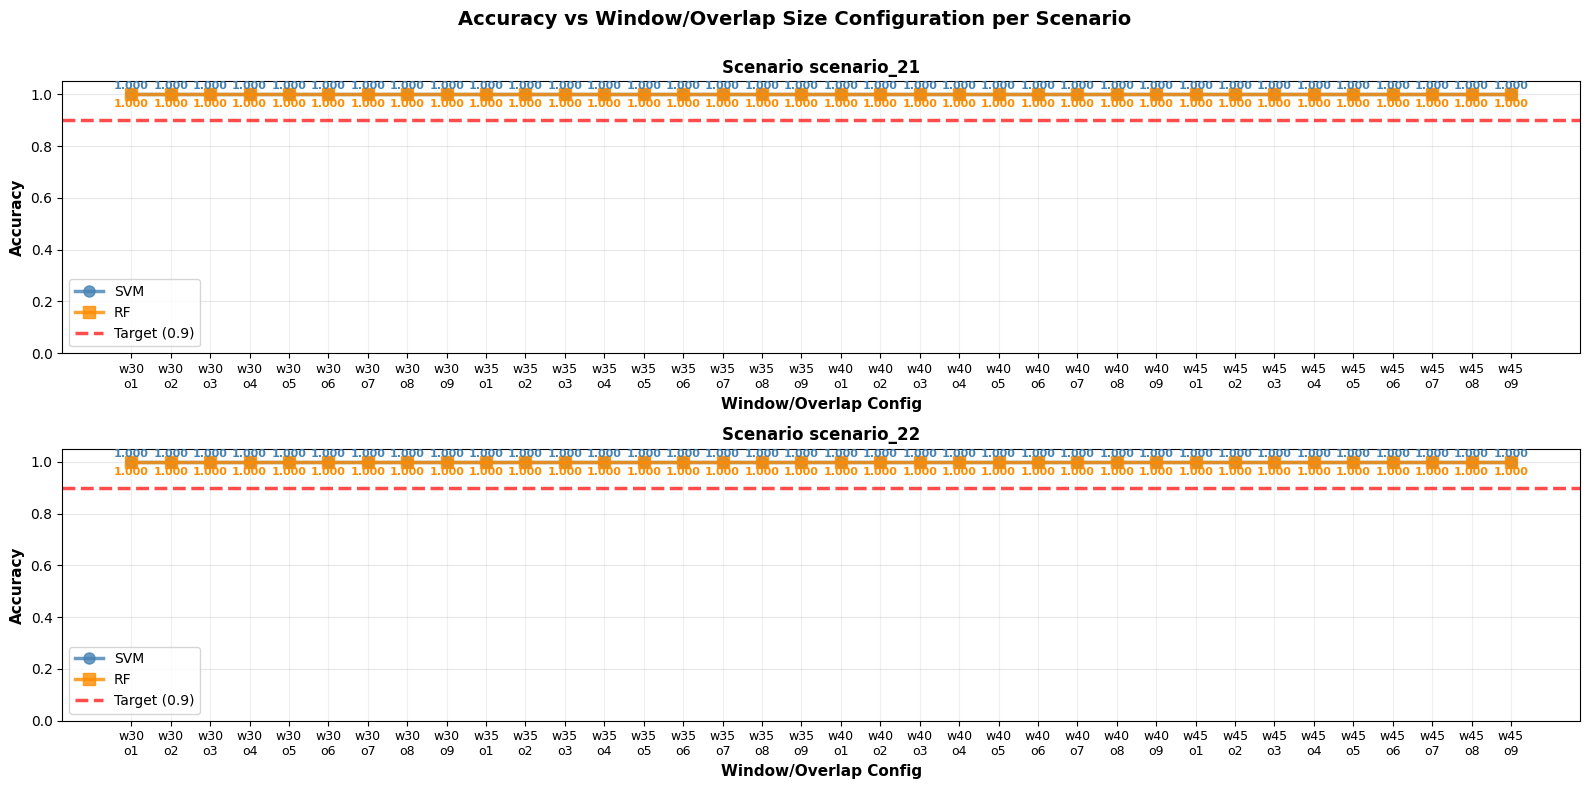


PARAMETER STUDY SUMMARY - Accuracy Results

scenario_21:
Config          SVM Accuracy       RF Accuracy        Avg Accuracy      
----------------------------------------------------------------------
w30_o1          1.0000             1.0000             1.0000            
w30_o2          1.0000             1.0000             1.0000            
w30_o3          1.0000             1.0000             1.0000            
w30_o4          1.0000             1.0000             1.0000            
w30_o5          1.0000             1.0000             1.0000            
w30_o6          1.0000             1.0000             1.0000            
w30_o7          1.0000             1.0000             1.0000            
w30_o8          1.0000             1.0000             1.0000            
w30_o9          1.0000             1.0000             1.0000            
w35_o1          1.0000             1.0000             1.0000            
w35_o2          1.0000             1.0000             1.0000        

In [52]:
# Visualization of parameter study results
scenario_keys_sorted = sorted(
    param_study_results[list(param_study_results.keys())[0]].keys()
)
config_keys = sorted(param_study_results.keys())

n_scenarios = len(scenario_keys_sorted)
fig, axes = plt.subplots(n_scenarios, 1, figsize=(16, 4 * n_scenarios), squeeze=False)
axes = axes.flatten()

for idx, scenario_key in enumerate(scenario_keys_sorted):
    ax = axes[idx]

    svm_accs = []
    rf_accs = []
    config_labels = []

    for config_key in config_keys:
        if scenario_key in param_study_results[config_key]:
            svm_accs.append(
                param_study_results[config_key][scenario_key]["SVM"]["accuracy"]
            )
            rf_accs.append(
                param_study_results[config_key][scenario_key]["RF"]["accuracy"]
            )

            # Extract window and overlap from config key
            window = config_key.split("_")[0][1:]
            overlap = config_key.split("_")[1][1:]
            config_labels.append(f"w{window}\no{overlap}")

    x = np.arange(len(config_labels))

    # Add line plots
    ax.plot(
        x,
        svm_accs,
        marker="o",
        linewidth=2.5,
        markersize=8,
        label="SVM",
        color="steelblue",
        alpha=0.8,
    )
    ax.plot(
        x,
        rf_accs,
        marker="s",
        linewidth=2.5,
        markersize=8,
        label="RF",
        color="darkorange",
        alpha=0.8,
    )

    # Add horizontal reference line at 0.9 accuracy
    ax.axhline(
        y=0.9,
        color="red",
        linestyle="--",
        linewidth=2.5,
        alpha=0.7,
        label="Target (0.9)",
    )

    ax.set_xlabel("Window/Overlap Config", fontsize=11, fontweight="bold")
    ax.set_ylabel("Accuracy", fontsize=11, fontweight="bold")
    ax.set_title(f"Scenario {scenario_key}", fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(config_labels, fontsize=9)
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.grid(axis="x", alpha=0.2)

    # Add value labels at each point
    for i, (svm_acc, rf_acc) in enumerate(zip(svm_accs, rf_accs)):
        ax.text(
            i,
            svm_acc + 0.02,
            f"{svm_acc:.3f}",
            ha="center",
            fontsize=8,
            color="steelblue",
            fontweight="bold",
        )
        ax.text(
            i,
            rf_acc - 0.05,
            f"{rf_acc:.3f}",
            ha="center",
            fontsize=8,
            color="darkorange",
            fontweight="bold",
        )

plt.suptitle(
    "Accuracy vs Window/Overlap Size Configuration per Scenario",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


# Summary table
print("\n" + "=" * 100)
print("PARAMETER STUDY SUMMARY - Accuracy Results")
print("=" * 100)

for scenario_key in scenario_keys_sorted:
    print(f"\n{scenario_key}:")
    print(
        f"{'Config':<15} {'SVM Accuracy':<18} {'RF Accuracy':<18} {'Avg Accuracy':<18}"
    )
    print("-" * 70)

    for config_key in config_keys:
        if scenario_key in param_study_results[config_key]:
            svm_acc = param_study_results[config_key][scenario_key]["SVM"]["accuracy"]
            rf_acc = param_study_results[config_key][scenario_key]["RF"]["accuracy"]
            avg_acc = (svm_acc + rf_acc) / 2

            print(f"{config_key:<15} {svm_acc:<18.4f} {rf_acc:<18.4f} {avg_acc:<18.4f}")